# Building a stochastic event set

A ~120-year historical record contains too few landfalling storms to estimate
tail risk (100+ year return periods) with any precision. NatCat instead fits a
statistical model to the historical Atlantic best-track archive — genesis
locations, a Markov-like transition model over a coarse lat/lon grid, and a
Poisson storm count per year — and uses it to generate an arbitrarily long
*synthetic* event set that is statistically consistent with history but not
limited by its sample size.


In [1]:
import logging

logging.basicConfig(level=logging.INFO, format="%(message)s")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from natcat import plotting

plotting.apply_style()
pd.options.display.float_format = "{:,.2f}".format


NumExpr defaulting to 10 threads.


## The historical archive

NatCat trains on NHC ATCF B-deck files (`bal*.dat` for the Atlantic basin). The
full archive back to 1900 can be (re)downloaded with
`natcat.data.download_archive(range(1900, 2021), basin="al")`; here we use the
copy already cached under `../data/raw`.


In [2]:
from pathlib import Path

raw_dir = Path("../data/raw")
n_files = len(list(raw_dir.glob("bal*.dat")))
print(f"{n_files} Atlantic best-track files cached locally under {raw_dir}")


1550 Atlantic best-track files cached locally under ../data/raw


## Fitting the catalog

`SyntheticTCCatalog.fit` parses every file, builds the genesis KDE, the
transition table, and fits the annual storm-count (Poisson) rate.


In [3]:
import time

from natcat.stochastic import SyntheticTCCatalog

t0 = time.perf_counter()
catalog = SyntheticTCCatalog(seed=42).fit("../data/raw")
print(f"Fitted in {time.perf_counter() - t0:.1f}s")
print(f"{len(catalog.tracks)} tracks parsed, {len(catalog.failed_files)} files skipped (malformed or unparsable)")
print(f"Fitted annual frequency (Poisson rate): {catalog.frequency.rate:.2f} storms/year")


Loaded 1495 tracks (55 skipped).


Fitted on 1495 tracks: 1352 states, lambda=12.36 storms/year.


Fitted in 14.9s
1495 tracks parsed, 55 files skipped (malformed or unparsable)
Fitted annual frequency (Poisson rate): 12.36 storms/year


## Genesis: historical vs. synthetic

Genesis points are resampled from a Gaussian KDE fitted to historical
first-detection positions. Overlaying historical and KDE-sampled points is a
quick visual check that the model reproduces the main genesis regions (Cabo
Verde, western Caribbean, Gulf of Mexico).


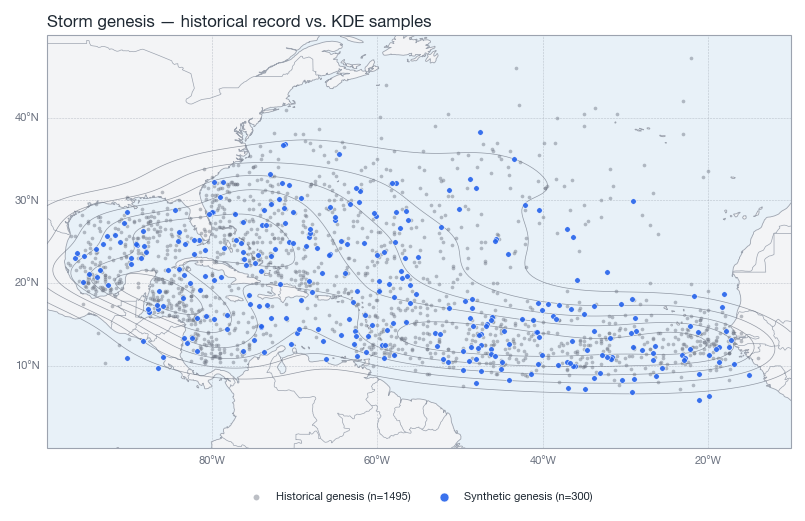

In [4]:
from natcat.stochastic.genesis import extract_genesis_points

historical_genesis = extract_genesis_points(catalog.tracks)
synthetic_genesis = catalog.genesis.sample(300, rng=np.random.default_rng(0))

fig, ax = plotting.plot_genesis(
    historical_genesis,
    synthetic_genesis,
    kde=catalog.genesis.kde,
    title="Storm genesis — historical record vs. KDE samples",
)


## Transition model

Storm motion is simulated by sampling an observed historical transition from
whichever grid cell the storm currently occupies. The state space is coarse
(2° cells) but dense where storms are common.


1352 occupied grid cells (state space)


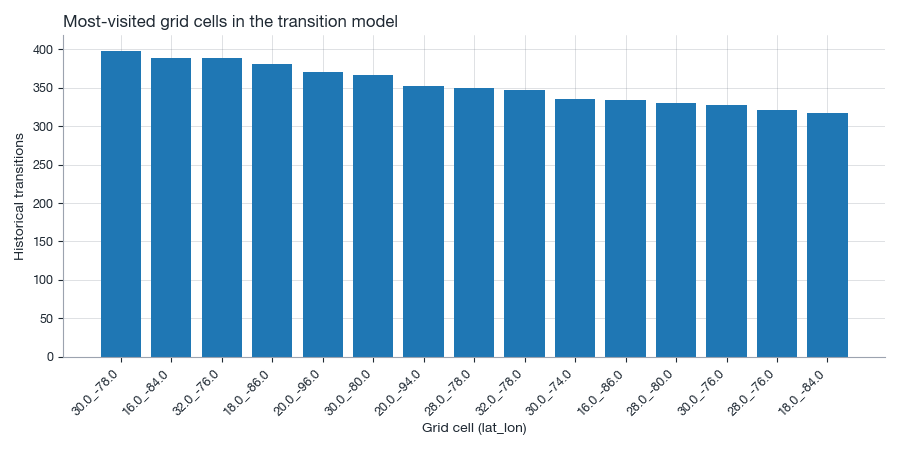

In [5]:
print(f"{catalog.transitions.n_states} occupied grid cells (state space)")

counts = sorted(
    ((state, len(options)) for state, options in catalog.transitions.table.items()),
    key=lambda kv: -kv[1],
)[:15]
states, n_transitions = zip(*counts)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(states, n_transitions)
ax.set_ylabel("Historical transitions")
ax.set_xlabel("Grid cell (lat_lon)")
ax.set_title("Most-visited grid cells in the transition model")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()


## Inland decay

Over land a tropical cyclone loses its energy source, so `LandDecayModel` relaxes the wind towards a background value instead of decaying it to zero, following Kaplan & DeMaria (1995). The rate and background wind are fitted by least squares to every historical landfall in `catalog.tracks`, rather than assumed, so the synthetic set reproduces the observed hours of hurricane- and storm-force wind over land. The fit below (rate 0.069/h, background wind 25.3 kt, RMSE 8.7 kt) replaces a legacy rule that had no background wind and an RMSE of 21 kt, which made synthetic storms lose hurricane strength inland several times faster than observed.

LandDecayModel(rate_per_h=0.0693, floor_kt=25.3, n_points=6762, rmse_kt=8.7)


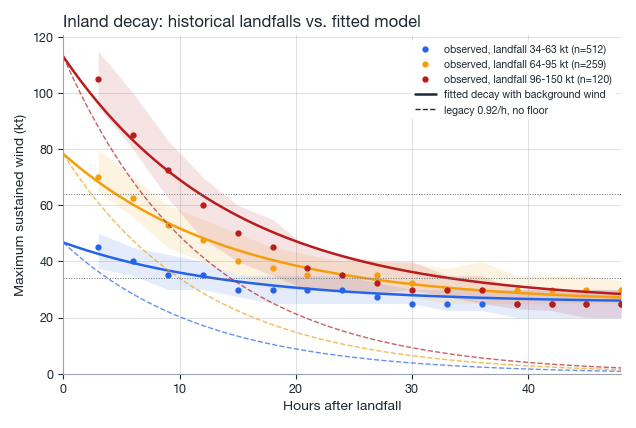

In [6]:
from natcat.stochastic import extract_landfall_segments

print(catalog.land_decay)
segments = extract_landfall_segments(catalog.tracks)
fig, ax = plotting.plot_land_decay(
    catalog.land_decay, segments, title="Inland decay: historical landfalls vs. fitted model"
)

## Generating synthetic years

`generate(n_years=...)` draws a Poisson storm count for each year, a genesis
point and intensity for each storm, and then walks the storm through the
transition model (with land-decay applied) until it dissipates.


In [7]:
synthetic_catalog = catalog.generate(n_years=10)
print(f"{synthetic_catalog['storm_id'].nunique()} synthetic storms across 10 simulated years")
synthetic_catalog.head()


134 synthetic storms across 10 simulated years


,storm_id,time,hour,latitude,longitude,max_wind_speed_kt,radius_max_wind_nm,translation_speed_kt,heading_deg,year
0,SYN_000000,1900-01-01 00:00:00,0.00,12.99,-77.43,25.00,25.66,4.01,75.54,0
1,SYN_000000,1900-01-01 03:00:00,3.00,13.04,-77.23,25.00,25.68,4.45,334.02,0
2,SYN_000000,1900-01-01 06:00:00,6.00,13.24,-77.33,27.50,25.32,5.58,224.18,0
3,SYN_000000,1900-01-01 09:00:00,9.00,13.04,-77.53,27.50,25.32,10.24,331.65,0
4,SYN_000000,1900-01-01 12:00:00,12.00,13.49,-77.78,30.00,25.05,8.83,276.56,0


In [8]:
storms_per_year = synthetic_catalog.groupby("year")["storm_id"].nunique()
max_intensity_per_storm = synthetic_catalog.groupby("storm_id")["max_wind_speed_kt"].max()

summary = pd.DataFrame(
    {
        "storms_per_year (mean)": [storms_per_year.mean()],
        "storms_per_year (std)": [storms_per_year.std()],
        "max_intensity (mean, kt)": [max_intensity_per_storm.mean()],
        "max_intensity (max, kt)": [max_intensity_per_storm.max()],
    }
)
summary


,storms_per_year (mean),storms_per_year (std),"max_intensity (mean, kt)","max_intensity (max, kt)"
0,13.40,2.46,62.38,180.00


## Category distribution: historical vs. synthetic

We classify each storm's lifetime-maximum wind speed on the Saffir-Simpson
scale and compare the historical and synthetic distributions side by side.


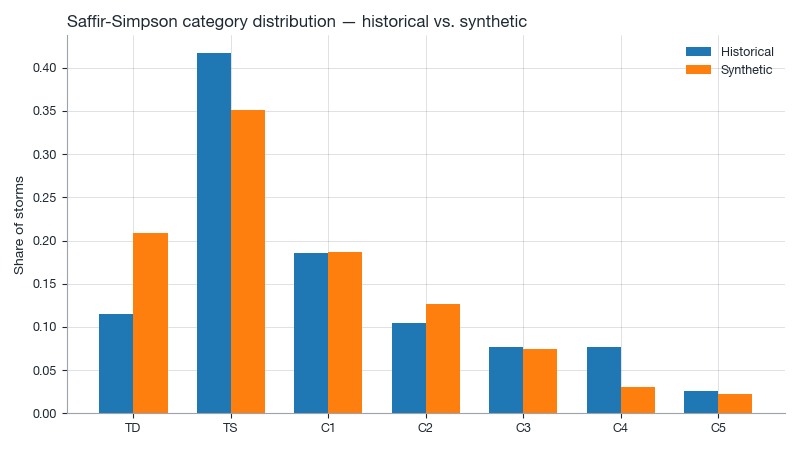

In [9]:
from natcat.utils import saffir_simpson_category

historical_max_wind = pd.Series(
    [t["max_wind_speed_kt"].max() for t in catalog.tracks]
)
categories = ["TD", "TS", "C1", "C2", "C3", "C4", "C5"]

hist_counts = (
    pd.Series(saffir_simpson_category(historical_max_wind.to_numpy()))
    .value_counts(normalize=True)
    .reindex(categories, fill_value=0.0)
)
synth_counts = (
    pd.Series(saffir_simpson_category(max_intensity_per_storm.to_numpy()))
    .value_counts(normalize=True)
    .reindex(categories, fill_value=0.0)
)

x = np.arange(len(categories))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, hist_counts.values, width, label="Historical")
ax.bar(x + width / 2, synth_counts.values, width, label="Synthetic")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Share of storms")
ax.set_title("Saffir-Simpson category distribution — historical vs. synthetic")
ax.legend()
fig.tight_layout()


A single synthetic track, plotted the same way as any historical best track:


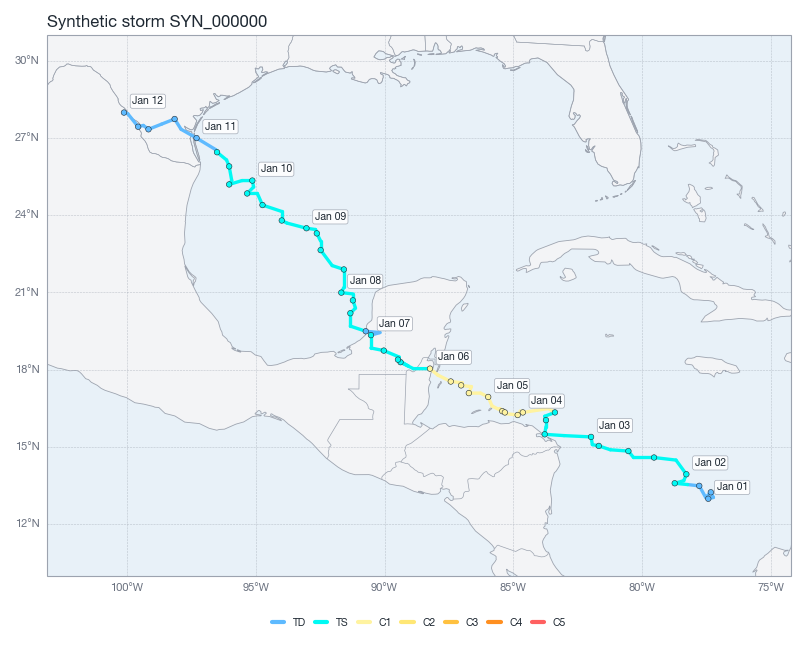

In [10]:
first_storm_id = synthetic_catalog["storm_id"].iloc[0]
sample_track = synthetic_catalog[synthetic_catalog["storm_id"] == first_storm_id]

fig, ax = plotting.plot_track(sample_track, title=f"Synthetic storm {first_storm_id}")


## Historical sample vs. synthetic event set

Comparing a random sample of 150 historical tracks against the 10-year
synthetic catalog over the full Atlantic basin gives a qualitative sense of
whether the synthetic tracks are exploring the same genesis regions,
recurvature patterns and landfall corridors as history.


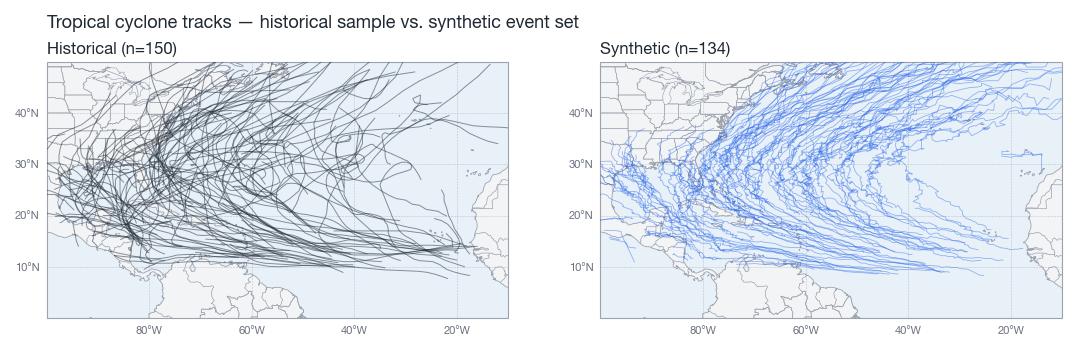

In [11]:
rng = np.random.default_rng(42)
sample_size = min(150, len(catalog.tracks))
indices = rng.choice(len(catalog.tracks), size=sample_size, replace=False)
historical_sample = [catalog.tracks[i] for i in indices]

fig, axes = plotting.plot_catalog_comparison(
    historical_sample,
    synthetic_catalog,
    extent=(-100, -10, 0, 50),
    max_storms=150,
    title="Tropical cyclone tracks — historical sample vs. synthetic event set",
)


## Limitations

- The transition model operates on a 2° grid, so fine-scale track curvature
  (e.g. tight recurvature near the coast) is smoothed out.
- Inland decay is a single fitted exponential relation (`catalog.land_decay`), pooling
  every historical landfall; it does not vary by terrain, storm size, or approach angle.
- The Poisson frequency model has no seasonality or interannual variability
  (e.g. ENSO), so synthetic years do not reproduce active/quiet season
  clustering seen historically.
- Per-step intensity and radius-of-maximum-wind draws are capped (`max_wind_kt=185.0`, `max_rmw_nm=150.0`) to keep the Markov step physically plausible; these caps can occasionally bind for the most extreme synthetic storms.
